# Decision Analysis - Project 1

### 1. Dataset Description

**Dataset:**
The data comes from the Otomoto website and includes listings for 15 popular cars on the Polish used car market (filter: Car for city). 

For the decision analysis, we selected 5 criteria, which we've divided into cost-type attributes (to be minimized) and gain-type attributes (to be maximized):

- Price in PLN (price_pln) – a cost-type criterion. Obvious choice: the lower the purchase price, the more preferable the option.

- Year of manufacture (year_of_manufacture) – a profit-type criterion. Another obvious choice: newer models are rated higher.

- Mileage (mileage_km) – a cost-type criterion. (at this point it seems that clearly all choices are obvious) We want the lowest possible mileage.

- Fuel consumption (fuel_consumption_l100km) – a cost-type criterion. We also want possible lowest fuel consumption.

- Appearance (appearance) – a benefit-type criterion. A subjective assessment of visual appeal on a scale of 1–10 (where 10 represents the most attractive car).

### 2. Data Source
Data was scrapped by hand from Otomoto. Filter was:
- Year of production: 2014 - 2016
- Price: 30000 - 50000
- Segment: City

### 3. The point of view of the decision maker
The decision maker is average driver/buyer looking for a car for everyday use. He prioritize reliability (so low mileage and newer model year are better) and low running costs (price, fuel consumption), but do not want to completely sacrifice driving dynamics (power) and aesthetics.

### 4. What is the number of alternatives considered? Were there more of them in the original data set?
Exactly 15 alternatives are being considered. Otomoto has thousands of offers, so we selected only 15 of them.

### 5. Describe one of the alternatives considered
Renault Clio (ID 10):
- Price: 34 000 PLN (Cost)
- Year: 2016 (Gain)
- Mileage: 76 270 km (Cost)
- Power: 90 KM (Gain)
- Fuel Consumption: 5.8 L/100km (Cost)
- Apperance: 6 (Gain)

### 6. What is the number of criteria considered? Were there more of them in the original data set?
Six criteria are being considered (price, model year, mileage, horsepower, fuel economy, and appearance). We selected these six from the original set because they are the most important from the perspective of the decision-maker (the average buyer in the used car market). In our dataset there are more of them, but they are useless for us (as id or link - which is only for verification that our dataset is real)

### 7. Domains and nature of criteria

- price: Continuous, range: [30900, 49999], type: Cost
- year: Discrete, values: [2014, 2015, 2016], type: Gain
- mileage: Continuous, range: [71,000, 188,000], type: Cost
- power: Continuous, range: [86, 218], type: Gain
- fuel_consumption: Continuous, range: [5.1, 8.9], type: Cost
- appearance: Discrete, values: [4, 5, 6, 7, 8, 9], type: Gain

### 8. Are all criteria equally important? What about weightings?
No, the criteria are not equally important. The most important factors are cost-effectiveness and mechanical condition.
Estimated weights on a scale of 1-10:
- Price: 9
- Mileage: 8
- Appearance: 6
- Fuel economy: 6
- Power: 4
- Year of manufacture: 2

There are no criteria that are completely “unimportant,” but Power and Year of manufacture (as they are only 3 values) are of marginal importance when choosing an inexpensive city car.

### 9. Are there dominated alternatives?
In our dataset, there are no strictly dominant alternatives (where car A is better than or equal to car B on absolutely all criteria). For example, the cheaper car always has inferior features or appearance, while the car with lower mileage is more expensive or has less power.

### 10. What should the theoretically best alternative look like?
The best theoretical alternative is cheap, with low mileage with good apperance, but for example with less power than others

### 11. Which alternative seems to be the best?
Hyundai i20 (ID 2) - due to low fuel consumption (5.1), low mileage (71200) and very good apperance (7/10). It has weaknesses (the worst possible year of production)

### 12. Which alternative seems to be the worst?
Ford Focus (ID 13) - due to the absolutely highest mileage in the dataset (188000), relatively high fuel consumption (7.2) and only an average price (35900). It has strengths (good power 150 HP, decent appearance 7/10, and the newest year of production.)

### 13. Provide at least 4 pairwise comparisons between alternatives in your dataset. 
- Renault Clio (ID 10) > Skoda Fabia (ID 11) – due to lower mileage (76,270 vs. 124,000) at very simillar price and fuel economy.
- Hyundai i20 (ID 2) > Toyota Yaris (ID 8) – due to a lower price (36,950 vs. 41,500), lower mileage (71,200 vs. 119,000), lower fuel consumption, and better appearance. The Yaris wins only in the criteria with the lowest weight (model year and power). 
- Seat Ibiza (ID 9) > Ford Focus (ID 13) - due to the best price (30,900 vs. 35,900) and lower mileage (156,000 vs. 188,000), which, given the preferences, is enough to rule out the Focus. 
- Kia Venga (ID 1) > Chevrolet Trax (ID 6) - due to its lower price (32,500 vs. 34,900) and lower mileage (82,000 vs. 97,500), which is much more important than the Chevrolet higher power.

In [2]:
import pandas as pd
import pulp
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('cars_dataset.csv')
df.columns = df.columns.str.strip()
df.set_index('id', inplace=True)
CRITERIA = ['price', 'year', 'mileage', 'fuel_consumption', 'appearance']
df = df[CRITERIA + ['name']]
display(df.head())

,price,year,mileage,fuel_consumption,appearance,name
id,,,,,,
1,32500,2015,82000,7.6,4,Kia Venga
2,36950,2014,71200,5.1,7,Huinda i20
3,33800,2014,180686,8.0,9,BMW 118d
4,37900,2016,135000,7.2,7,Renault Megane
5,38700,2015,180000,6.2,6,Nissan Qashqai


## 2.1 Implementacja UTA z obsługą sprzeczności

W tej sekcji wykorzystano wariant metody UTA.
Wprowadzonych zostało 5 sensownych preferencji parami, np. Auto 2 > Auto 1 oraz dodatkowe trzy wyroki tworzące celowo logiczny cykl (#3 > #4, #4 > #5, #5 > #3), aby wymusić sprzeczność w modelu.

Zgodnie z wymaganiami model zawiera:
- Ograniczenia zapobiegające płaskim i w pełni liniowym funkcjom użyteczności (parametr epsilon).
- Ograniczenia wag – żadne > 0.5 i żadne < 0.1 (min_weight i max_weight).
- Rozwiązywanie sprzeczności – wykrycie i wypisanie min. podzbiorów ograniczeń do usunięcia.

In [9]:
# breakpoints for each criterion
BP = {
    'price': [30000,40000,50000],
    'year': [2014,2015,2016],
    'mileage': [70000,130000,190000],
    'fuel_consumption': [5.0,7.0,9.0],
    'appearance': [4,7,10],
}
DIRECTIONS = {
    'price':'cost',
    'year':'gain',
    'mileage':'cost',
    'fuel_consumption':'cost',
    'appearance':'gain',
}

EPS = 0.02
MIN_W = 0.10
MAX_W = 0.50
BIG_M = 1e3

PREFS = [
    (2,  1), # Hyundai i20 > Kia Venga (lower price, lower mileage, lower fuel)
    (10, 11), # Renault Clio > Skoda Fabia (lower mileage at same price tier)
    (2,  8), # Hyundai i20 > Toyota Yaris (cheaper, lower mileage, better appearance)
    (9,  13), # Seat Ibiza > Ford Focus (cheapest vs highest mileage)
    (1,  6), # Kia Venga > Chevrolet Trax (lower price, lower mileage)
    # cycle
    (3,  4), # BMW 118d > Renault Megane
    (4,  5), # Renault Megane > Nissan Qashqai
    (5,  3), # Nissan Qashqai > BMW 118d
]

PREF_LABELS = {
    (2,  1):  "Hyundai i20 > Kia Venga",
    (10, 11): "Renault Clio > Skoda Fabia",
    (2,  8):  "Hyundai i20 > Toyota Yaris",
    (9,  13): "Seat Ibiza > Ford Focus",
    (1,  6):  "Kia Venga > Chevrolet Trax",
    (3,  4):  "BMW 118d > Renault Megane  [cycle]",
    (4,  5):  "Renault Megane > Nissan Qashqai  [cycle]",
    (5,  3):  "Nissan Qashqai > BMW 118d  [cycle]",
}
print(f"breakpoints defined, preferences: {len(PREFS)} total")


breakpoints defined, preferences: 8 total


In [10]:
def get_utility(car_id, u_vars):
    row = df.loc[car_id]
    result = pulp.lpSum([])

    for crit in CRITERIA:
        pts = BP[crit]
        val = float(row[crit])
        val = max(pts[0], min(pts[-1], val))

        seg = len(pts) - 2
        for i in range(len(pts) - 1):
            if val <= pts[i + 1]:
                seg = i
                break

        x0 = pts[seg]
        x1 = pts[seg + 1]
        u0 = u_vars[(crit, seg)]
        u1 = u_vars[(crit, seg + 1)]
        t = (val - x0) / (x1 - x0)
        result = result + u0 + t * (u1 - u0)

    return result


def build_model(model_name, pref_list, use_binary=False):
    model = pulp.LpProblem(model_name, pulp.LpMinimize)

    u = {}
    for crit in CRITERIA:
        for k in range(len(BP[crit])):
            u[(crit, k)] = pulp.LpVariable(f"u_{crit}_{k}", lowBound=0)

    for crit in CRITERIA:
        pts = BP[crit]
        for k in range(len(pts) - 1):
            if DIRECTIONS[crit] == 'gain':
                model += u[(crit, k+1)] - u[(crit, k)] >= EPS
            else:
                model += u[(crit, k)] - u[(crit, k+1)] >= EPS

    for crit in CRITERIA:
        pts = BP[crit]
        if DIRECTIONS[crit] == 'gain':
            model += u[(crit, 0)] == 0
        else:
            model += u[(crit, len(pts)-1)] == 0

    weight_list = []
    for crit in CRITERIA:
        pts = BP[crit]
        if DIRECTIONS[crit] == 'gain':
            w = u[(crit, len(pts)-1)]
        else:
            w = u[(crit, 0)]
        model += w >= MIN_W
        model += w <= MAX_W
        weight_list.append(w)

    model += pulp.lpSum(weight_list) == 1

    bin_vars = {}
    for i in range(len(pref_list)):
        a, b = pref_list[i]
        ua = get_utility(a, u)
        ub = get_utility(b, u)
        if use_binary:
            v = pulp.LpVariable(f"v_{i}", cat=pulp.const.LpBinary)
            bin_vars[i] = v
            model += ua - ub + BIG_M * v >= EPS
        else:
            model += ua - ub >= EPS

    model += 0
    return model, u, bin_vars


m1, u1, bv1 = build_model('find_min_removals', PREFS, use_binary=True)
m1 += pulp.lpSum(bv1.values())
m1.solve(pulp.PULP_CBC_CMD(msg=False))

n_remove = int(round(pulp.value(m1.objective)))
print(f"Status: {pulp.LpStatus[m1.status]}")
print(f"Min removals: {n_remove}")
print()

found = []
cuts = []

for it in range(10):
    m, u_it, bv = build_model(f'enum_{it}', PREFS, use_binary=True)
    m += pulp.lpSum(bv.values())
    m += pulp.lpSum(bv.values()) == n_remove

    for prev in cuts:
        m += pulp.lpSum(bv[i] for i in prev) <= n_remove - 1

    m.solve(pulp.PULP_CBC_CMD(msg=False))
    if m.status != 1:
        break

    removed = [i for i in range(len(PREFS)) if pulp.value(bv[i]) > 0.5]
    kept = [PREFS[i] for i in range(len(PREFS)) if i not in removed]

    found.append({'removed': [PREFS[i] for i in removed], 'consistent': kept})
    cuts.append(removed)

print(f"Found {len(found)} consistent subset(s):\n")
for k in range(len(found)):
    print(f"Subset {k+1}:")
    print(f"Removed: {[PREF_LABELS[p] for p in found[k]['removed']]}")
    print(f"Kept: {len(found[k]['consistent'])} preferences")
    print()

Status: Optimal
Min removals: 1

Found 3 consistent subset(s):

Subset 1:
Removed: ['BMW 118d > Renault Megane  [cycle]']
Kept: 7 preferences

Subset 2:
Removed: ['Renault Megane > Nissan Qashqai  [cycle]']
Kept: 7 preferences

Subset 3:
Removed: ['Nissan Qashqai > BMW 118d  [cycle]']
Kept: 7 preferences



c:\Users\jakub\AppData\Local\Programs\Python\Python312\Lib\site-packages\pulp\pulp.py:1865: UserWarning: Overwriting previously set objective.
  warnings.warn("Overwriting previously set objective.")


- Hyundai i20 > Kia Venga
- Renault Clio > Skoda Fabia
- Hyundai i20 > Toyota Yaris
- Seat Ibiza > Ford Focus
- Kia Venga > Chevrolet Trax
- Renault Megane > Nissan Qashqai  [cycle]
- Nissan Qashqai > BMW 118d  [cycle]

status: Optimal

weights:
price: 0.100
year: 0.100
mileage: 0.100
fuel_consumption: 0.428
appearance: 0.272


,name,utility,price,year,mileage,fuel_consumption,appearance
id,,,,,,,
2,Huinda i20,0.802386,36950,2014,71200,5.1,7
10,Renault Clio,0.692422,34000,2016,76270,5.8,6
11,Skoda Fabia,0.651595,33700,2016,124000,5.7,6
9,Seat Ibiza,0.577929,30900,2016,156000,6.5,7
15,Honda Jazz,0.564394,33200,2014,100400,5.4,5
12,Renault Captur,0.425102,41000,2015,109400,6.7,8
4,Renault Megane,0.424861,37900,2016,135000,7.2,7
13,Ford Focus,0.423194,35900,2016,188000,7.2,7
5,Nissan Qashqai,0.404861,38700,2015,180000,6.2,6


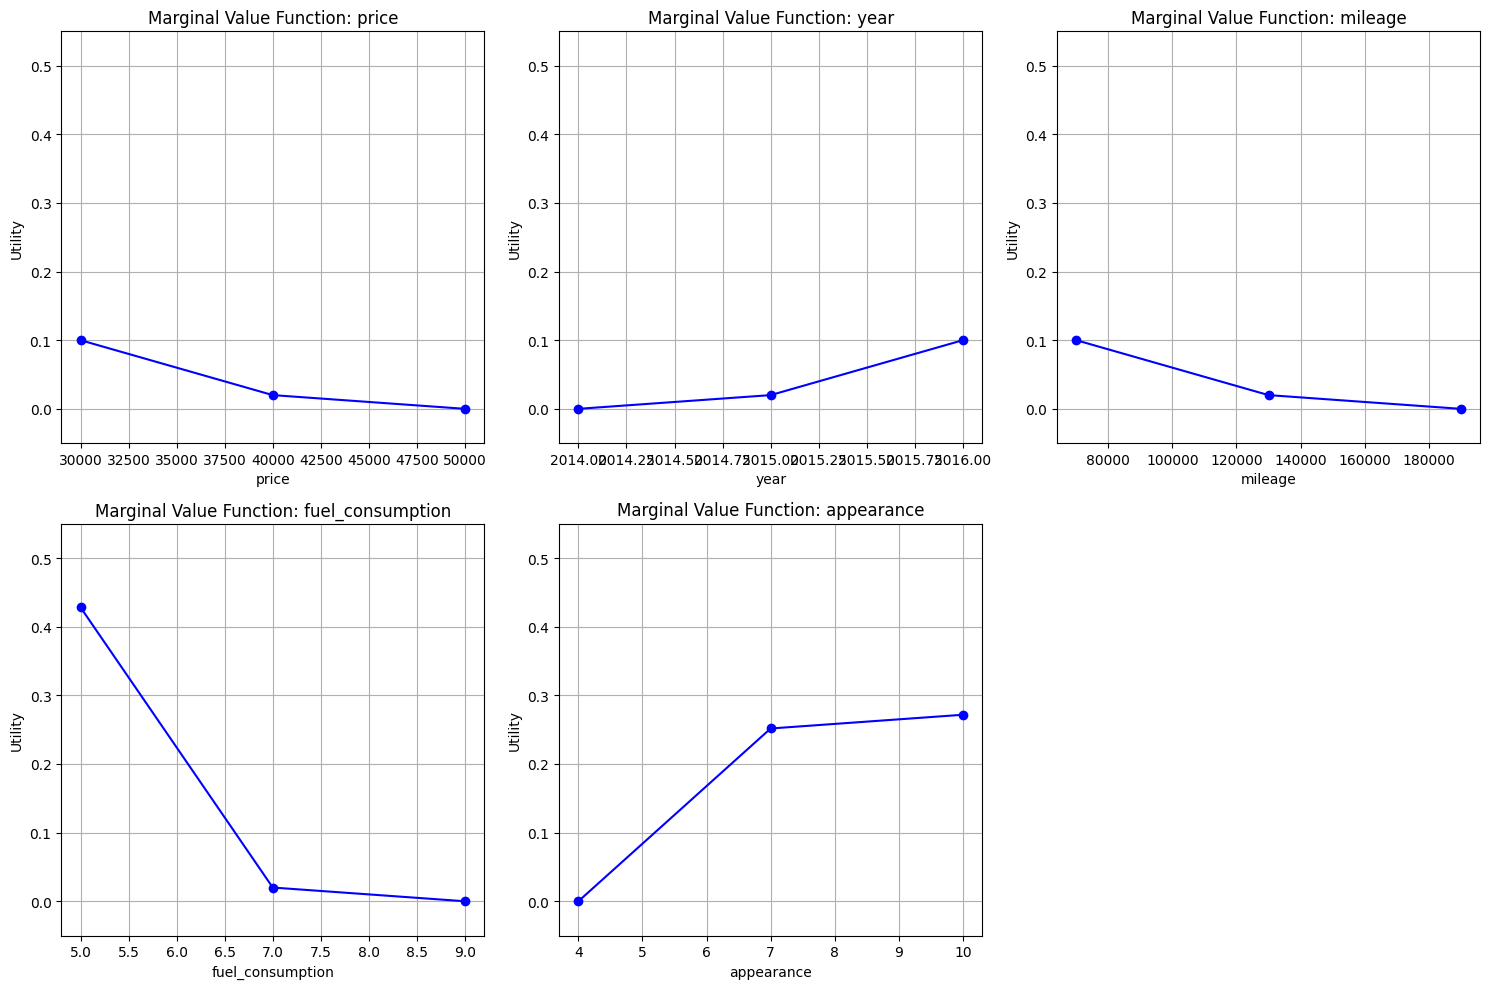

In [11]:
selected_prefs = found[0]['consistent']
for p in selected_prefs:
    print(f"- {PREF_LABELS[p]}")

m_final, u_final, _ = build_model('uta_consistent_set', selected_prefs, use_binary=False)

m_final.solve(pulp.PULP_CBC_CMD(msg=False))
print(f"\nstatus: {pulp.LpStatus[m_final.status]}")

weights = {}
for crit in CRITERIA:
    pts = BP[crit]
    if DIRECTIONS[crit] == 'gain':
        w = pulp.value(u_final[(crit, len(pts)-1)])
    else:
        w = pulp.value(u_final[(crit, 0)])
    weights[crit] = w

print("\nweights:")
for crit, w in weights.items():
    print(f"{crit}: {w:.3f}")

utilities = {}
for car_id in df.index:
    val = pulp.value(get_utility(car_id, u_final))
    utilities[car_id] = val

df_res = df.copy()
df_res['utility'] = pd.Series(utilities)
df_res = df_res.sort_values('utility', ascending=False)
display(df_res[['name', 'utility'] + CRITERIA].head(15))

plt.figure(figsize=(15, 10))
for i, crit in enumerate(CRITERIA):
    plt.subplot(2, 3, i + 1)
    
    x_vals = BP[crit]
    y_vals = [pulp.value(u_final[(crit, k)]) for k in range(len(x_vals))]

    plt.plot(x_vals, y_vals, marker='o', linestyle='-', color='b')
    plt.title(f"Marginal Value Function: {crit}")
    plt.xlabel(crit)
    plt.ylabel("Utility")
    plt.ylim(-0.05, 0.55)
    plt.grid(True)

plt.tight_layout()
plt.show()